1. Install and import libraries

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

2. Dataset Acquisition

In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00519/heart_failure_clinical_records_dataset.csv"

df = pd.read_csv(url)

print("Dataset downloaded successfully.")

Dataset downloaded successfully.


3. Load Dataset

In [4]:
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


4. Summarize Dataset

In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Number of rows: 299
Number of columns: 13

Data Types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

Missing Values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


5. Visualize Missing Values

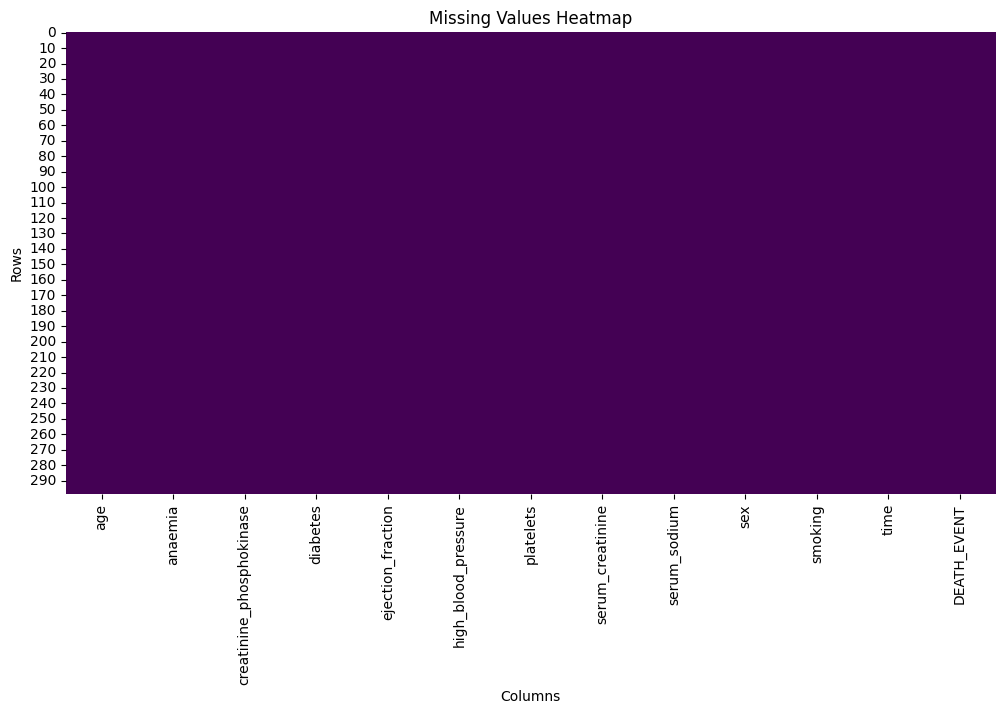

In [6]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

6. Plot Distributions

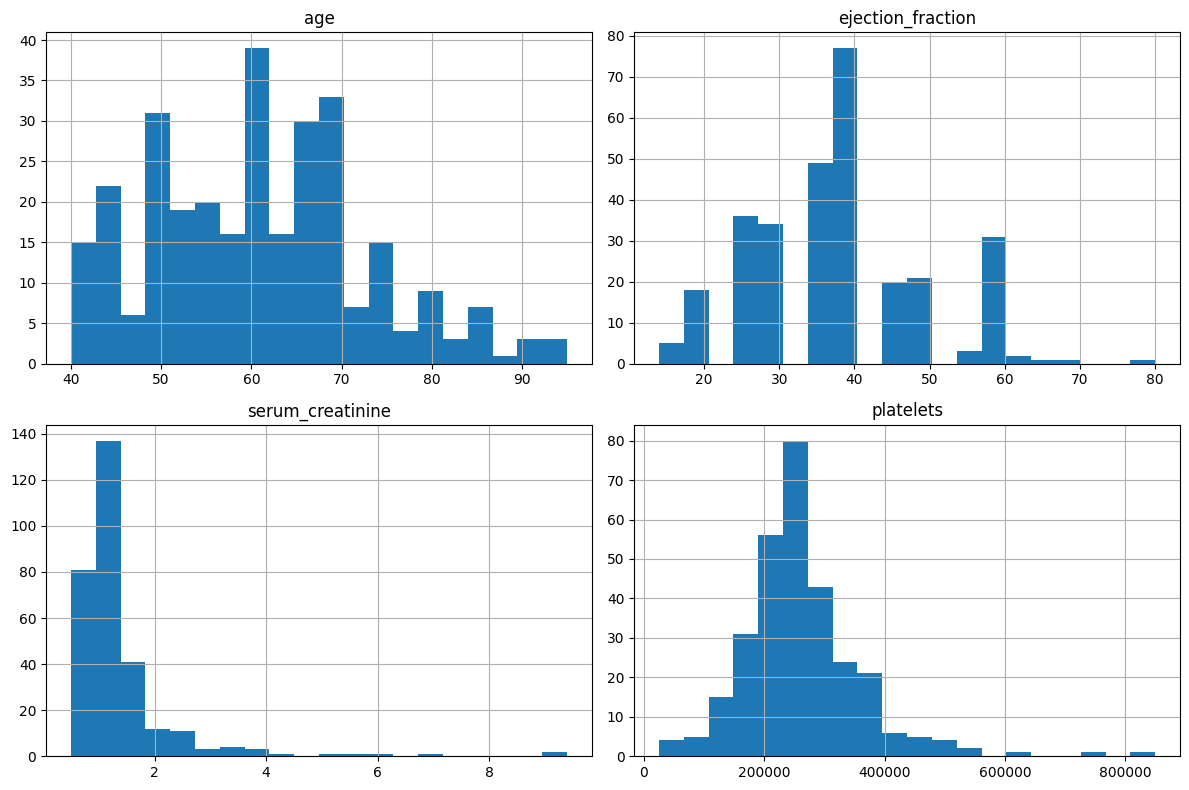

In [7]:
numerical_features = [
    "age",
    "ejection_fraction",
    "serum_creatinine",
    "platelets"
]

df[numerical_features].hist(
    figsize=(12, 8),
    bins=20
)

plt.tight_layout()
plt.show()

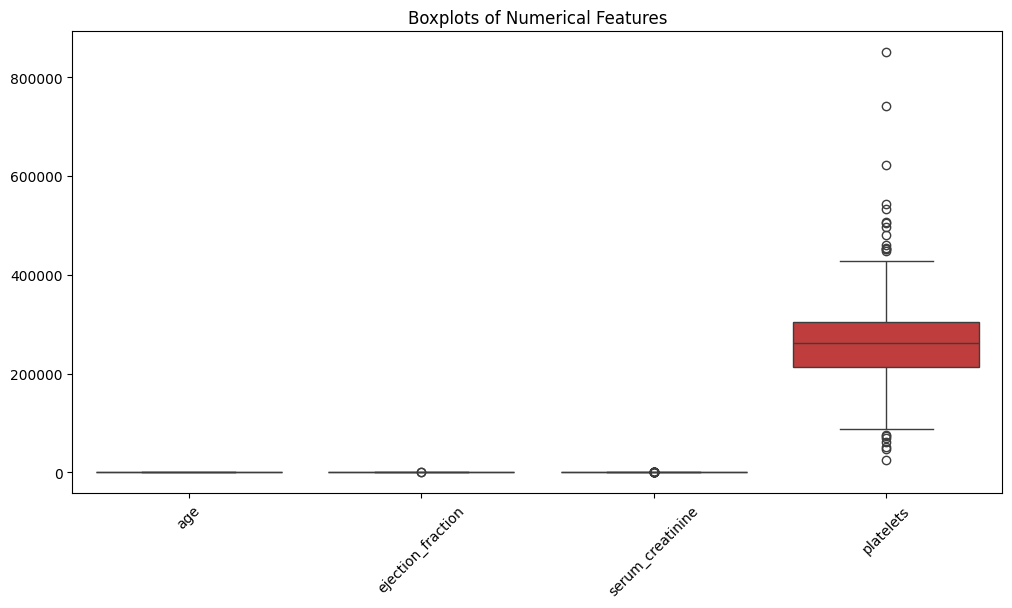

In [8]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df[numerical_features])

plt.title("Boxplots of Numerical Features")
plt.xticks(rotation=45)
plt.show()

7. Impute Missing Values

In [9]:
numerical_columns = df.select_dtypes(
    include=np.number
).columns

for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

In [10]:
categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

8. Remove Outliers

In [11]:
numerical_columns = df.select_dtypes(
    include=np.number
).columns

Q1 = df[numerical_columns].quantile(0.25)
Q3 = df[numerical_columns].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[
    ~(
        (df[numerical_columns] < lower_bound) |
        (df[numerical_columns] > upper_bound)
    ).any(axis=1)
]

print("Dataset shape after removing outliers:")
print(df.shape)

Dataset shape after removing outliers:
(224, 13)


9. Correct Inconsistencies

In [12]:
print("Minimum age before correction:", df["age"].min())

Minimum age before correction: 40.0


In [13]:
# Remove rows with invalid negative age
df = df[df["age"] >= 0]

print("Minimum age after correction:", df["age"].min())

Minimum age after correction: 40.0


10. Feature Engineering

In [14]:
def age_group(age):
    if age < 40:
        return "<40"
    elif age <= 60:
        return "40-60"
    else:
        return ">60"

df["age_group"] = df["age"].apply(age_group)

print(df[["age", "age_group"]].head())

    age age_group
0  75.0       >60
2  65.0       >60
3  50.0     40-60
5  90.0       >60
6  75.0       >60


In [15]:
df["risk_score"] = (
    df["ejection_fraction"] *
    df["serum_creatinine"]
)

In [16]:
risk_scaler = MinMaxScaler()

df["risk_score"] = risk_scaler.fit_transform(
    df[["risk_score"]]
)

print(df[["ejection_fraction", "serum_creatinine", "risk_score"]].head())

   ejection_fraction  serum_creatinine  risk_score
0                 20               1.9    0.310545
2                 20               1.3    0.171495
3                 20               1.9    0.310545
5                 40               2.1    0.843569
6                 15               1.2    0.078795


11. Encode Categorical Variables

In [17]:
categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    dtype=int
)

display(df.head())

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,risk_score,age_group_40-60,age_group_>60
0,75.0,0,582,0,20,1,265000.0,1.9,130,1,0,4,1,0.310545,0,1
2,65.0,0,146,0,20,0,162000.0,1.3,129,1,1,7,1,0.171495,0,1
3,50.0,1,111,0,20,0,210000.0,1.9,137,1,0,7,1,0.310545,1,0
5,90.0,1,47,0,40,1,204000.0,2.1,132,1,1,8,1,0.843569,0,1
6,75.0,1,246,0,15,0,127000.0,1.2,137,1,0,10,1,0.078795,0,1


12. Normalize Features

In [18]:
numerical_columns = df.select_dtypes(
    include=np.number
).columns

scaler = MinMaxScaler()

df[numerical_columns] = scaler.fit_transform(
    df[numerical_columns]
)

display(df.head())

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,risk_score,age_group_40-60,age_group_>60
0,0.636364,0.0,0.470990,0.0,0.117647,1.0,0.468852,0.866667,0.217391,1.0,0.0,0.000000,1.0,0.310545,0.0,1.0
2,0.454545,0.0,0.098976,0.0,0.117647,0.0,0.131148,0.466667,0.173913,1.0,1.0,0.010676,1.0,0.171495,0.0,1.0
3,0.181818,1.0,0.069113,0.0,0.117647,0.0,0.288525,0.866667,0.521739,1.0,0.0,0.010676,1.0,0.310545,1.0,0.0
5,0.909091,1.0,0.014505,0.0,0.509804,1.0,0.268852,1.000000,0.304348,1.0,1.0,0.014235,1.0,0.843569,0.0,1.0
6,0.636364,1.0,0.184300,0.0,0.019608,0.0,0.016393,0.400000,0.521739,1.0,0.0,0.021352,1.0,0.078795,0.0,1.0


13. Compute Summary Statistics

In [19]:
original_df = pd.read_csv(url)

original_numerical = original_df.select_dtypes(
    include=np.number
).columns

In [20]:
before_statistics = pd.DataFrame({
    "Mean": original_df[original_numerical].mean(),
    "Median": original_df[original_numerical].median(),
    "Standard Deviation": original_df[original_numerical].std()
})

print("Statistics Before Cleaning:")
display(before_statistics)

Statistics Before Cleaning:


,Mean,Median,Standard Deviation
age,60.833893,60.0,11.894809
anaemia,0.431438,0.0,0.496107
creatinine_phosphokinase,581.839465,250.0,970.287881
diabetes,0.418060,0.0,0.494067
ejection_fraction,38.083612,38.0,11.834841
high_blood_pressure,0.351171,0.0,0.478136
platelets,263358.029264,262000.0,97804.236869
serum_creatinine,1.393880,1.1,1.034510
serum_sodium,136.625418,137.0,4.412477
sex,0.648829,1.0,0.478136


In [21]:
cleaned_numerical = df.select_dtypes(
    include=np.number
).columns

after_statistics = pd.DataFrame({
    "Mean": df[cleaned_numerical].mean(),
    "Median": df[cleaned_numerical].median(),
    "Standard Deviation": df[cleaned_numerical].std()
})

print("Statistics After Cleaning:")
display(after_statistics)

Statistics After Cleaning:


,Mean,Median,Standard Deviation
age,0.378355,0.363636,0.217202
anaemia,0.468750,0.000000,0.500140
creatinine_phosphokinase,0.261896,0.155290,0.238499
diabetes,0.419643,0.000000,0.494606
ejection_fraction,0.474090,0.470588,0.229624
high_blood_pressure,0.379464,0.000000,0.486340
platelets,0.438902,0.460656,0.220176
serum_creatinine,0.352381,0.333333,0.218530
serum_sodium,0.523680,0.521739,0.165510
sex,0.642857,1.000000,0.480231


14. Validate Cleaning

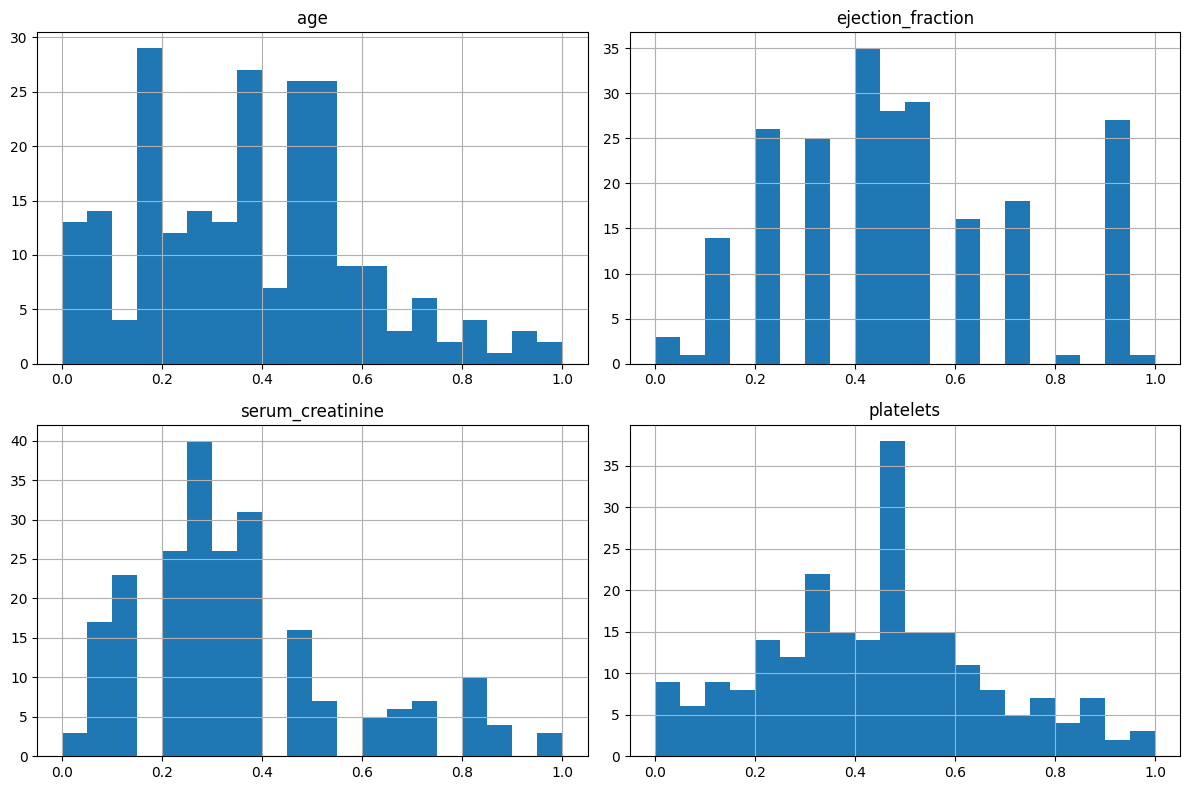

In [22]:
numerical_features = [
    "age",
    "ejection_fraction",
    "serum_creatinine",
    "platelets"
]

df[numerical_features].hist(
    figsize=(12, 8),
    bins=20
)

plt.tight_layout()
plt.show()

15. Check Missing Values

In [23]:
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
risk_score                  0
age_group_40-60             0
age_group_>60               0
dtype: int64


In [24]:
if df.isnull().sum().sum() == 0:
    print("No missing values remain.")
else:
    print("Missing values still remain.")

No missing values remain.
